MODEL TRANING


LIBRARIES

In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.model_selection import RandomizedSearchCV
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor, AdaBoostRegressor
import warnings

In [40]:
%pip install catboost xgboost

  Using cached catboost-1.2.10-cp314-cp314-win_amd64.whl.metadata (1.5 kB)
  Using cached xgboost-3.4.0-py3-none-win_amd64.whl.metadata (2.0 kB)
  Using cached graphviz-0.21-py3-none-any.whl.metadata (12 kB)
  Using cached plotly-6.9.0-py3-none-any.whl.metadata (9.0 kB)
Using cached catboost-1.2.10-cp314-cp314-win_amd64.whl (101.7 MB)
Using cached xgboost-3.4.0-py3-none-win_amd64.whl (48.9 MB)
Using cached graphviz-0.21-py3-none-any.whl (47 kB)
Using cached plotly-6.9.0-py3-none-any.whl (9.9 MB)

   ---------------------------------------- 0/4 [plotly]
   ---------------------------------------- 0/4 [plotly]
   ---------------------------------------- 0/4 [plotly]
   ---------------------------------------- 0/4 [plotly]
   ---------------------------------------- 0/4 [plotly]
   ---------------------------------------- 0/4 [plotly]
   ---------------------------------------- 0/4 [plotly]
   ---------------------------------------- 0/4 [plotly]
   ---------------------------------------


[notice] A new release of pip is available: 25.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [41]:
from catboost import CatBoostRegressor
from xgboost import XGBRegressor

In [26]:
##Importing dataset

data=pd.read_csv('data/stud.csv')

First five rows

In [27]:
data.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


Preparing X and Y

In [28]:
X=data.drop('math_score', axis=1)
y=data['math_score']

In [29]:
X.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,reading_score,writing_score
0,female,group B,bachelor's degree,standard,none,72,74
1,female,group C,some college,standard,completed,90,88
2,female,group B,master's degree,standard,none,95,93
3,male,group A,associate's degree,free/reduced,none,57,44
4,male,group C,some college,standard,none,78,75


In [30]:
y

0      72
1      69
2      90
3      47
4      76
       ..
995    88
996    62
997    59
998    68
999    77
Name: math_score, Length: 1000, dtype: int64

In [31]:
print("Categories in 'gender' variable:     ",end=" " )
print(data['gender'].unique())

print("Categories in 'race_ethnicity' variable:  ",end=" ")
print(data['race_ethnicity'].unique())

print("Categories in'parental level of education' variable:",end=" " )
print(data['parental_level_of_education'].unique())

print("Categories in 'lunch' variable:     ",end=" " )
print(data['lunch'].unique())

print("Categories in 'test preparation course' variable:     ",end=" " )
print(data['test_preparation_course'].unique())

Categories in 'gender' variable:      <StringArray>
['female', 'male']
Length: 2, dtype: str
Categories in 'race_ethnicity' variable:   <StringArray>
['group B', 'group C', 'group A', 'group D', 'group E']
Length: 5, dtype: str
Categories in'parental level of education' variable: <StringArray>
[ 'bachelor's degree',       'some college',    'master's degree',
 'associate's degree',        'high school',   'some high school']
Length: 6, dtype: str
Categories in 'lunch' variable:      <StringArray>
['standard', 'free/reduced']
Length: 2, dtype: str
Categories in 'test preparation course' variable:      <StringArray>
['none', 'completed']
Length: 2, dtype: str


### Create Column Transformer with 3 types of transformers

In [32]:
num_features=X.select_dtypes(exclude='object').columns
cat_features=X.select_dtypes(include='object').columns

from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer

one_hot=OneHotEncoder()
Std=StandardScaler()

preprocessor=ColumnTransformer(
[
    ("OneHotEncoder", one_hot, cat_features),
    ("StandardScaler", Std, num_features)
]
)

C:\Users\Admin\AppData\Local\Temp\ipykernel_22628\958034420.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_features=X.select_dtypes(include='object').columns


In [33]:
X=preprocessor.fit_transform(X)

In [34]:
X.shape

(1000, 19)

In [35]:
##Splititng dataset into train and test
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test=train_test_split(X,y, test_size=0.20, random_state=42)
X_train.shape, X_test.shape 

((800, 19), (200, 19))

#### Creating an Evaluate Function to give all metrics after model Training

In [44]:
def evaluate_model(true, predicted):
    mae=mean_absolute_error(true, predicted)
    mse=mean_squared_error(true, predicted)
    rmse=np.sqrt(mse)
    r_2_score=r2_score(true, predicted)
    return mae, rmse, r_2_score

In [47]:
models={
    "Linear": LinearRegression(),
    "Lasso" : Lasso(),
    "Rideg" : Ridge(),
    "K-Neighbors Regressor": KNeighborsRegressor(),
    "Decision Tree": DecisionTreeRegressor(),
    "Random Forest Regressor": RandomForestRegressor(),
    "XGBRegressor": XGBRegressor(), 
    "CatBoosting Regressor": CatBoostRegressor(verbose=False),
    "AdaBoost Regressor": AdaBoostRegressor()
}
model_list=[]
r2_list=[]
for i in range(len(list(models))):
    model=list(models.values())[i]
    model.fit(X_train, y_train) #traing Model
    
    #Prediction 
    y_pred_train=model.predict(X_train)
    y_pred_test=model.predict(X_test)
    
    #Evalute train and test dataset
    model_train_mae, model_train_rmse, model_train_r2=evaluate_model(y_train, y_pred_train)
    
    model_test_mae, model_test_rmse, model_test_r2=evaluate_model(y_test, y_pred_test)
    
    print(list(models.keys())[i])
    model_list.append(list(models.keys())[i])
    
    print("Model Performace for taring dataset")
    print("--mean absolute error {:.4f}".format(model_train_mae))
    print("--root mean Squred error {:.4f}".format(model_train_rmse))
    print("--R2 Score {:.4f}".format(model_train_r2))
    
    print("-------------------------------------------------------------")
    
    print("Model performance for test dataset")
    print("--mean absolute error {:.4f}".format(model_test_mae))
    print("--root mean Squred error {:.4f}".format(model_test_rmse))
    print("--R2 Score {:.4f}".format(model_test_r2))
    r2_list.append(model_test_r2)
    
    print("="*35)
    
    print('\n')


Linear
Model Performace for taring dataset
--mean absolute error 4.2667
--root mean Squred error 5.3231
--R2 Score 0.8743
-------------------------------------------------------------
Model performance for test dataset
--mean absolute error 4.2148
--root mean Squred error 5.3940
--R2 Score 0.8804


Lasso
Model Performace for taring dataset
--mean absolute error 5.2063
--root mean Squred error 6.5938
--R2 Score 0.8071
-------------------------------------------------------------
Model performance for test dataset
--mean absolute error 5.1579
--root mean Squred error 6.5197
--R2 Score 0.8253


Rideg
Model Performace for taring dataset
--mean absolute error 4.2650
--root mean Squred error 5.3233
--R2 Score 0.8743
-------------------------------------------------------------
Model performance for test dataset
--mean absolute error 4.2111
--root mean Squred error 5.3904
--R2 Score 0.8806


K-Neighbors Regressor
Model Performace for taring dataset
--mean absolute error 4.5167
--root mean Squ

In [51]:
pd.DataFrame(list(zip(model_list, r2_list)), columns=['Model Name', 'r2_score']).sort_values(by=["r2_score"],ascending=False)

,Model Name,r2_score
2,Rideg,0.880593
0,Linear,0.880433
7,CatBoosting Regressor,0.851632
8,AdaBoost Regressor,0.850493
5,Random Forest Regressor,0.848417
6,XGBRegressor,0.827797
1,Lasso,0.825320
3,K-Neighbors Regressor,0.783813
4,Decision Tree,0.719218


LINEAR REGRESSION

In [54]:
lin_model=LinearRegression(fit_intercept=True)
lin_model=lin_model.fit(X_train, y_train)
y_pred=lin_model.predict(X_test)
score=r2_score(y_test, y_pred)*100
print("Accuracy of linear regression model is %.2f " %score)


Accuracy of linear regression model is 88.04 


Ploting Y_pred and y_test

Text(0, 0.5, 'predicted value')

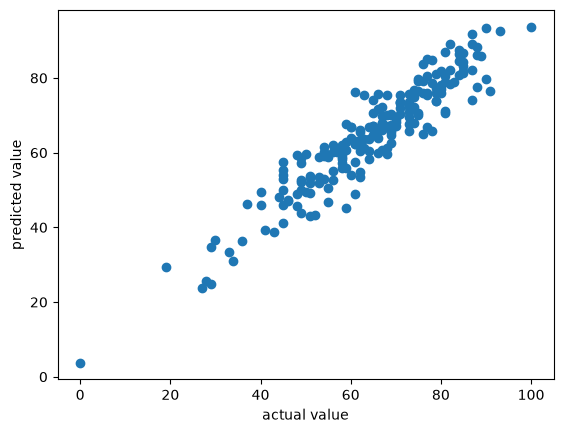

In [55]:
plt.scatter(y_test, y_pred)
plt.xlabel("actual value")
plt.ylabel("predicted value")

<Axes: xlabel='math_score'>

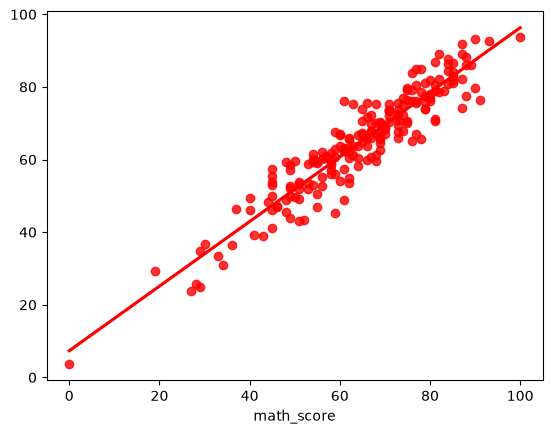

In [56]:
sns.regplot(x=y_test, y=y_pred, ci=None, color="red")

differance between actual and predicted values

In [57]:
pred_diff=pd.DataFrame({'Actual value':y_test, 'Predicted value':y_pred, "Differnce":y_test-y_pred})
pred_diff

,Actual value,Predicted value,Differnce
521,91,76.387970,14.612030
737,53,58.885970,-5.885970
740,80,76.990265,3.009735
660,74,76.851804,-2.851804
411,84,87.627378,-3.627378
...,...,...,...
408,52,43.409149,8.590851
332,62,62.152214,-0.152214
208,74,67.888395,6.111605
613,65,67.022287,-2.022287
